# Big Data and Data Mining – Assignment Report

**Exercise 1 (UK Traffic Accident Analysis)**

## Setup & Configuration

In [53]:
# Importing all necessary libraries here
import sqlite3 as sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from matplotlib.patches import Patch

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

In [54]:
# Connection to the accident db file
con = sql.connect('accident_data_v1.0.0_2023.db')
cur = con.cursor()

# Lookup dictionaries for categorical variables
severity = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
days = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
days_in_week = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
lights = {1: 'Daylight', 4: 'Dark-Lit', 5: 'Dark-Unlit', 6: 'Dark-No Lighting', 7: 'Dark-Unknown', -1: 'Unknown'}
weather_conditions = {1: 'Fine', 2: 'Raining', 3: 'Snowing', 4: 'Fine+Wind', 5: 'Rain+Wind', 6: 'Snow+Wind', 7: 'Fog', 8: 'Other', 9: 'Unknown', -1: 'Unknown'}
road_conditions = {1: 'Dry', 2: 'Wet/Damp', 3: 'Snow', 4: 'Frost/Ice', 5: 'Flood', 9: 'Unknown', -1: 'Unknown'}
speed = {-1: 'Unknown', 20: '20mph', 30: '30mph', 40: '40mph', 50: '50mph', 60: '60mph', 70: '70mph'}
area_condition = {1: 'Urban', 2: 'Rural', 3: 'Unallocated', -1: 'Unknown'}
moto_types = {3: 'Motorcycle ≤125cc', 4: 'Motorcycle 126–500cc', 5: 'Motorcycle >500cc'}


## Data Loading & Cleaning

In [55]:
# Finding total tables in the database
cur.execute("SELECT name FROM sqlite_master WHERE TYPE = 'table' ")
tables = [row[0] for row in cur.fetchall()]
tables

['accident', 'casualty', 'vehicle', 'lsoa']

In [56]:
# Creating a new column in the vehicle table
try:
    cur.execute('ALTER TABLE vehicle ADD COLUMN accident_vehicle_id TEXT')
    con.commit()
except Exception:
    pass  # column already exists on re-run

# Concatenating the existing columns into the new one
cur.execute("""
    UPDATE vehicle 
    SET accident_vehicle_id = accident_index || '_' || vehicle_reference
    """)
cur.execute('SELECT accident_vehicle_id FROM vehicle LIMIT 5')
con.commit()

# Creating a matching column in the casualty table
try:
    cur.execute('ALTER TABLE casualty ADD COLUMN accident_vehicle_id TEXT')
    con.commit()
except Exception:
    pass  # column already exists on re-run

cur.execute("""
    UPDATE casualty 
    SET accident_vehicle_id = accident_index || '_' || vehicle_reference
    """)
cur.execute('SELECT accident_vehicle_id FROM casualty LIMIT 5')
con.commit()

In [57]:
# Converting all the tables into a dataframe and storing data for 2017, 2018, 2019
acc_all = pd.read_sql_query("SELECT * FROM accident WHERE accident_year in(2017, 2018, 2019)", con)
cas_all = pd.read_sql_query("SELECT * FROM casualty WHERE accident_year in(2017, 2018, 2019)", con)
veh_all = pd.read_sql_query("SELECT * FROM vehicle WHERE accident_year in(2017, 2018, 2019)", con)
lso_all = pd.read_sql_query("SELECT * FROM lsoa", con)

In [58]:
# Finding total records for 2017, 2018, 2019 in each table
data_tables = ['accident', 'casualty', 'vehicle']
for table in data_tables:
    cur.execute(f"SELECT COUNT(*) FROM {table} WHERE accident_year IN (2017, 2018, 2019)")
    count = cur.fetchone()[0]
    print(f"{table.title()}: {count:,}")

Accident: 370,153
Casualty: 484,748
Vehicle: 681,716


### Finding and replacing nulls

In [59]:
# Finding nulls in the Accident table
null_counts_acc = acc_all.isna().sum() # found nulls in the accident table only

# Finding nulls in the Vehicle table
null_counts_veh = veh_all.isna().sum()

# Finding nulls in the Casualty table
null_counts_cas = cas_all.isna().sum()

# Finding nulls in the LSOA table
null_counts_lso = lso_all.isna().sum()

print(f"""Accident Table:\n{null_counts_acc[null_counts_acc > 0]}\n
Vehicle Table:\n{null_counts_veh[null_counts_veh > 0]}\n
Casualty Table:\n{null_counts_cas[null_counts_cas > 0]}\n
LSOA Table:\n{null_counts_lso[null_counts_lso > 0]}\n""")

Accident Table:
location_easting_osgr     102
location_northing_osgr    102
longitude                 112
latitude                  112
dtype: int64

Vehicle Table:
Series([], dtype: int64)

Casualty Table:
Series([], dtype: int64)

LSOA Table:
Series([], dtype: int64)



### Finding and dropping duplicate accident records

In [ ]:
acc_all['non_null_count'] = acc_all.notna().sum(axis=1)
acc_all = acc_all.sort_values('non_null_count', ascending=False).drop_duplicates(subset='accident_index', keep='first')
acc_all = acc_all.drop(columns='non_null_count')
print(f'Rows after removing duplication: {len(acc_all):,}')

Rows after deduplication: 370,153


### Checking for year consistency in accident table

In [61]:
acc_all['date_parsed'] = pd.to_datetime(acc_all['date'], dayfirst=True, errors='coerce')
mismatched = acc_all['date_parsed'].dt.year != acc_all['accident_year']
print(f'Temporal mismatches: {mismatched.sum():,}')
acc_all = acc_all[~mismatched].drop(columns='date_parsed')

Temporal mismatches: 0


### Checking for orphaned records in the vehicle and casualty tables

In [62]:
orphaned = cas_all[~cas_all['accident_vehicle_id'].isin(veh_all['accident_vehicle_id'])]
print(f'Orphaned casualty records: {len(orphaned):,}')
cas_all = cas_all[cas_all['accident_vehicle_id'].isin(veh_all['accident_vehicle_id'])]

Orphaned casualty records: 0


### Finding and dropping police force values of -1 for use later

In [63]:
before = len(acc_all)
acc_all = acc_all[acc_all['police_force'] != -1]
print(f'Dropped {before - len(acc_all):,} unassigned police force records')

Dropped 0 unassigned police force records


### Finding and replacing -1 categorized as out of bound

In [64]:
# Sum of all -1 entries in Casualty Table
out_of_bound_cas = cas_all.isin([-1]).sum()
print(f"Casualty Table:\n{out_of_bound_cas[out_of_bound_cas > 0]}\n")

# Sum of all -1 entries in Vehicle Table
out_of_bound_veh = veh_all.isin([-1]).sum()
print(f"Vehicle Table:\n{out_of_bound_veh[out_of_bound_veh > 0]}\n")

# Sum of all -1 entries in Accident Table
out_of_bound_acc = acc_all.isin([-1]).sum()
print(f"Accident Table:\n{out_of_bound_acc[out_of_bound_acc > 0]}\n")

# Sum of all -1 entries in Accident Table
out_of_bound_lso = lso_all.isin([-1]).sum()
print(f"LSOA Table:\n{out_of_bound_lso[out_of_bound_lso > 0]}\n")

Casualty Table:
sex_of_casualty                         786
age_of_casualty                        8357
age_band_of_casualty                   8357
pedestrian_location                       5
car_passenger                           984
bus_or_coach_passenger                  160
pedestrian_road_maintenance_worker      189
casualty_type                            10
casualty_home_area_type               66839
casualty_imd_decile                   66872
dtype: int64

Vehicle Table:
vehicle_type                           791
towing_and_articulation               1864
vehicle_manoeuvre                     1149
vehicle_direction_from                4611
vehicle_direction_to                  5894
vehicle_location_restricted_lane      1275
junction_location                      527
skidding_and_overturning              1410
hit_object_in_carriageway             1236
vehicle_leaving_carriageway           1348
hit_object_off_carriageway              12
first_point_of_impact                 1634

In [65]:
# Imputing -1 in age of casualty table from vehicle table
cur.execute("""
    SELECT 
        c.age_of_casualty AS original_age,
        v.age_of_driver AS source_driver_age,
        CASE 
            WHEN c.age_of_casualty <= 0 THEN v.age_of_driver 
            ELSE c.age_of_casualty 
        END AS imputed_age
    FROM casualty c
    JOIN vehicle v ON c.accident_index = v.accident_index AND c.vehicle_reference = v.vehicle_reference
    WHERE c.casualty_class = 1 AND c.age_of_casualty <= 0;
    """)

sample_fixes = cur.fetchmany(5)
for row in sample_fixes:
    print(f"Original: {row[0]} -> Fixed with Driver Age: {row[1]}")

Original: -1 -> Fixed with Driver Age: -1
Original: -1 -> Fixed with Driver Age: -1
Original: -1 -> Fixed with Driver Age: -1
Original: -1 -> Fixed with Driver Age: -1
Original: -1 -> Fixed with Driver Age: -1


In [66]:
# Replacing placeholders with actual labels
def clean_accidents(df):
    df = df.copy()
    
    df['severity_label'] = df['accident_severity'].map(severity).fillna('Unknown')
    df['day_label'] = df['day_of_week'].map(days).fillna('Unknown')
    df['light_label'] = df['light_conditions'].map(lights).fillna('Unknown')
    df['weather_label'] = df['weather_conditions'].map(weather_conditions).fillna('Unknown')
    df['road_surf_label'] = df['road_surface_conditions'].map(road_conditions).fillna('Unknown')
    df['speed_label'] = df['speed_limit'].map(speed).fillna('Unknown')
    df['urban_label'] = df['urban_or_rural_area'].map(area_condition).fillna('Unknown')

    return df

acc_all  = clean_accidents(acc_all)
print(f"Replaced accident rows : {len(acc_all):,}")

Replaced accident rows : 370,153


### Filtering Reccords for 2018

In [67]:
acc_2018 = acc_all[acc_all['accident_year']==2018].copy()
cas_2018 = cas_all[cas_all['accident_year']==2018].copy()
veh_2018 = veh_all[veh_all['accident_year']==2018].copy()

# Stroing data in a dictionary to print
dfs = {"Accident": acc_2018, "Casualty": cas_2018, "Vehicle": veh_2018}

for name, df in dfs.items():
    print(f"{name} 2018: {len(df):,}")

Accident 2018: 122,635
Casualty 2018: 160,597
Vehicle 2018: 226,409


## Tasks

#### Hourly and Daily Accident Patterns (2018)

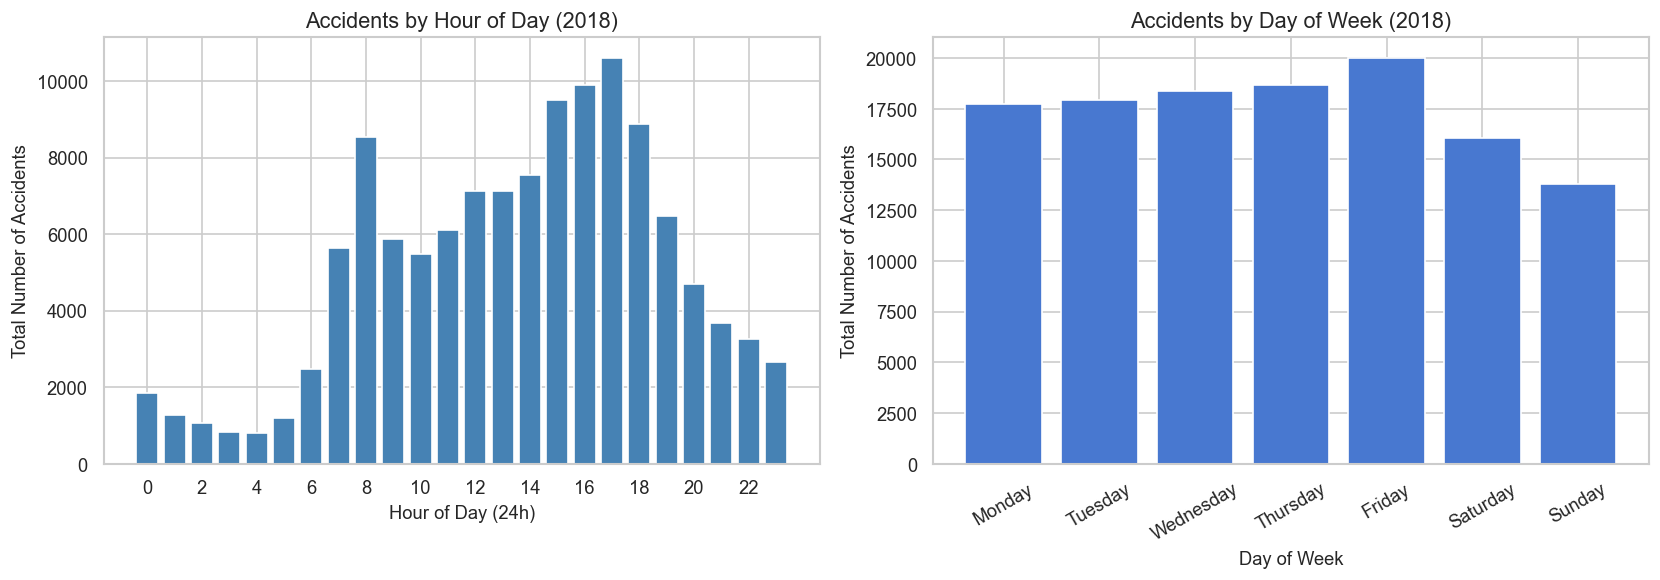

In [68]:
# Hourly spread of accidents
acc_2018['timestamp'] = pd.to_datetime(acc_2018['date'] + ' ' + acc_2018['time'], dayfirst=True)
acc_2018['hour'] = acc_2018['timestamp'].dt.hour
hourly = acc_2018.groupby('hour').size().reset_index(name='count')

# Daily distribution
daily = (acc_2018.groupby('day_label').size().reindex(days_in_week).reset_index(name='count'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly
axes[0].bar(hourly['hour'], hourly['count'], color='steelblue')
axes[0].set_title('Accidents by Hour of Day (2018)')
axes[0].set_xlabel('Hour of Day (24h)')
axes[0].set_ylabel('Total Number of Accidents')
axes[0].set_xticks(range(0, 24, 2))

# Daily plot
axes[1].bar(daily['day_label'], daily['count'])
axes[1].set_title('Accidents by Day of Week (2018)')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Number of Accidents')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('1_hourly+daily_accidents.png', bbox_inches='tight')
plt.show()

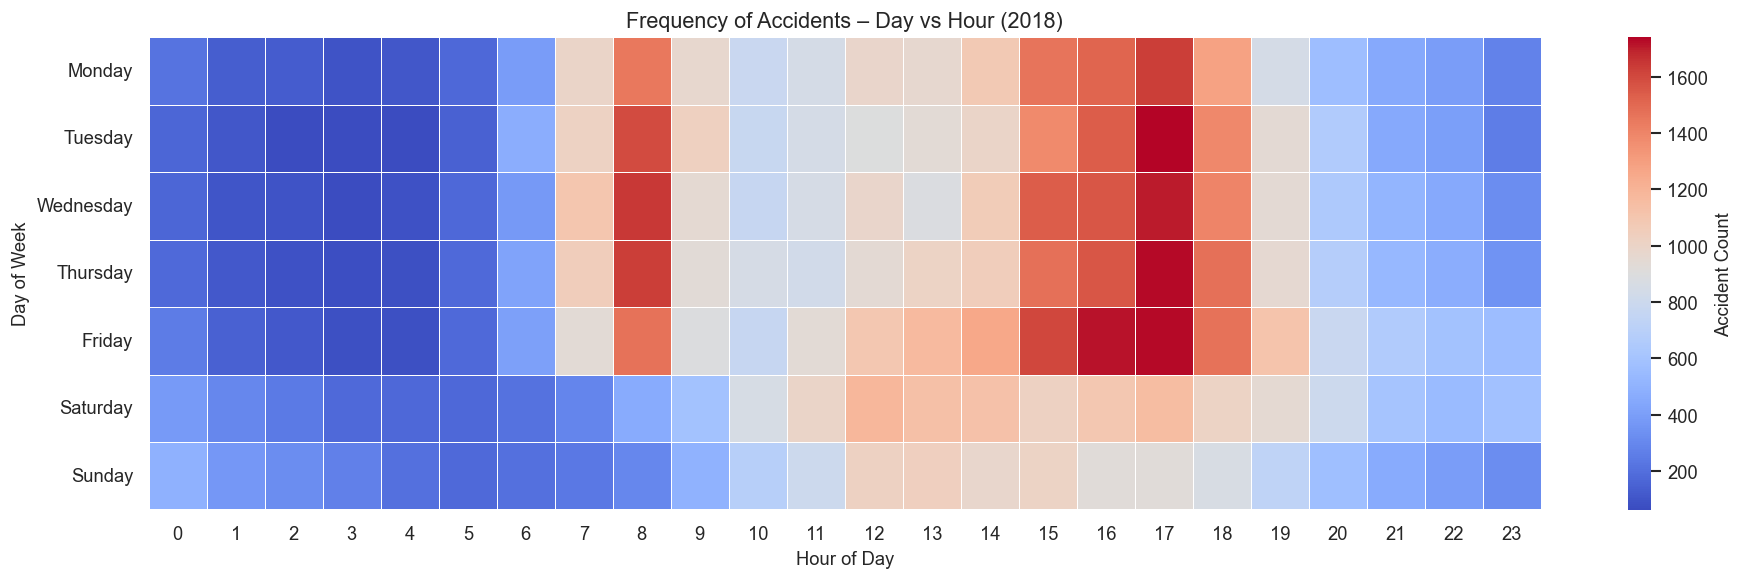

In [69]:
# Plotting hour vs day heat map
heatmap_2018 = (acc_2018.groupby(['day_label', 'hour']).size().unstack(fill_value=0).reindex(days_in_week))

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_2018, cmap='coolwarm', linewidths=0.3, ax=ax, cbar_kws={'label': 'Accident Count'})
ax.set_title('Frequency of Accidents – Day vs Hour (2018)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('task1_heatmap.png', bbox_inches='tight')
plt.show()

In [70]:
# Extracting all key stats
peak_hour = hourly.loc[hourly['count'].idxmax()]
peak_day = daily.loc[daily['count'].idxmax()]
print(f"Peak accident hour : {int(peak_hour['hour'])}:00  ({int(peak_hour['count']):,} accidents)")
print(f"Peak accident day : {peak_day['day_label']}  ({int(peak_day['count']):,} accidents)")
print("\nTop 5 hours:")
print(hourly.nlargest(5, 'count').to_string(index=False))

Peak accident hour : 17:00  (10,615 accidents)
Peak accident day : Friday  (20,021 accidents)

Top 5 hours:
 hour  count
   17  10615
   16   9905
   15   9500
   18   8891
    8   8538


---
#### Motorcycle Accidents by Hour and Day (2018)

In [71]:
# Filtering motorcycle records from the vehicle table (types 3, 4, 5)
moto_veh = veh_2018[veh_2018['vehicle_type'].isin(moto_types.keys())][['accident_index', 'vehicle_type']].copy()
moto_veh['bike_category'] = moto_veh['vehicle_type'].map(moto_types)

# Joining with accident data to get hour and day
moto = moto_veh.merge(acc_2018[['accident_index', 'hour', 'day_label']], on='accident_index', how='inner')

print(f"Total motorcycle accident records: {len(moto):,}")
print(moto['bike_category'].value_counts())

Total motorcycle accident records: 15,890
bike_category
Motorcycle ≤125cc       7774
Motorcycle >500cc       5876
Motorcycle 126–500cc    2240
Name: count, dtype: int64


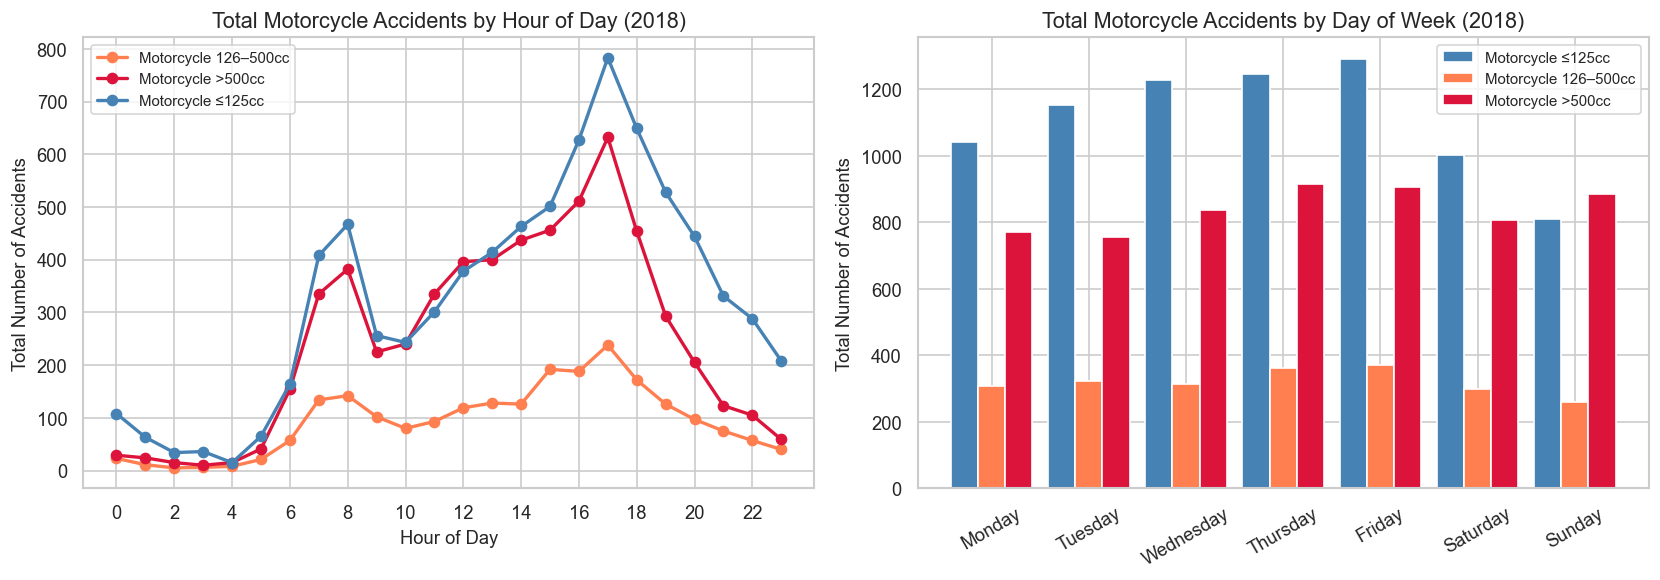

In [72]:
# Hourly accident counts per motorcycle category
hourly_moto = moto.groupby(['bike_category', 'hour']).size().reset_index(name='count')

# Daily accident counts per motorcycle category
daily_moto = moto.groupby(['bike_category', 'day_label']).size().reset_index(name='count')
daily_moto['day_label'] = pd.Categorical(daily_moto['day_label'], categories=days_in_week, ordered=True)
daily_moto = daily_moto.sort_values('day_label')

moto_palette = {'Motorcycle ≤125cc': 'steelblue', 'Motorcycle 126–500cc': 'coral', 'Motorcycle >500cc': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly line plot per category
for cat, grp in hourly_moto.groupby('bike_category'):
    axes[0].plot(grp['hour'], grp['count'], marker='o', label=cat, color=moto_palette[cat], linewidth=2)
axes[0].set_title('Total Motorcycle Accidents by Hour of Day (2018)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Number of Accidents')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)

# Grouped bar chart per day
x = np.arange(len(days_in_week))
width = 0.28
for i, cat in enumerate(moto_types.values()):
    subset = daily_moto[daily_moto['bike_category'] == cat]
    axes[1].bar(x + i * width, subset['count'], width, label=cat, color=moto_palette[cat])
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(days_in_week, rotation=30)
axes[1].set_title('Total Motorcycle Accidents by Day of Week (2018)')
axes[1].set_ylabel('Total Number of Accidents')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('2_motorcycle_accidents.png', bbox_inches='tight')
plt.show()

In [73]:
# Peak hour and peak day per motorcycle category
for cat in moto_types.values():
    subset = moto[moto['bike_category'] == cat]
    peak_h = subset['hour'].value_counts().idxmax()
    peak_d = subset['day_label'].value_counts().idxmax()
    print(f"{cat}: peak hour = {peak_h:02d}:00, peak day = {peak_d}, total accidents = {len(subset):,}")

Motorcycle ≤125cc: peak hour = 17:00, peak day = Friday, total accidents = 7,774
Motorcycle 126–500cc: peak hour = 17:00, peak day = Friday, total accidents = 2,240
Motorcycle >500cc: peak hour = 17:00, peak day = Thursday, total accidents = 5,876


---
#### Pedestrian Accidents by Hour and Day (2018)

In [74]:
# Filtering pedestrian casualties (casualty_class 3 denotes pedestrian)
ped_cas = cas_2018[cas_2018['casualty_class'] == 3][['accident_index']].drop_duplicates()

# Joining with accident data to retrieve information
ped = ped_cas.merge(acc_2018[['accident_index', 'hour', 'day_label']], on='accident_index', how='inner')

print(f"Distinct pedestrians involved accidents: {len(ped):,}")

Distinct pedestrians involved accidents: 21,644


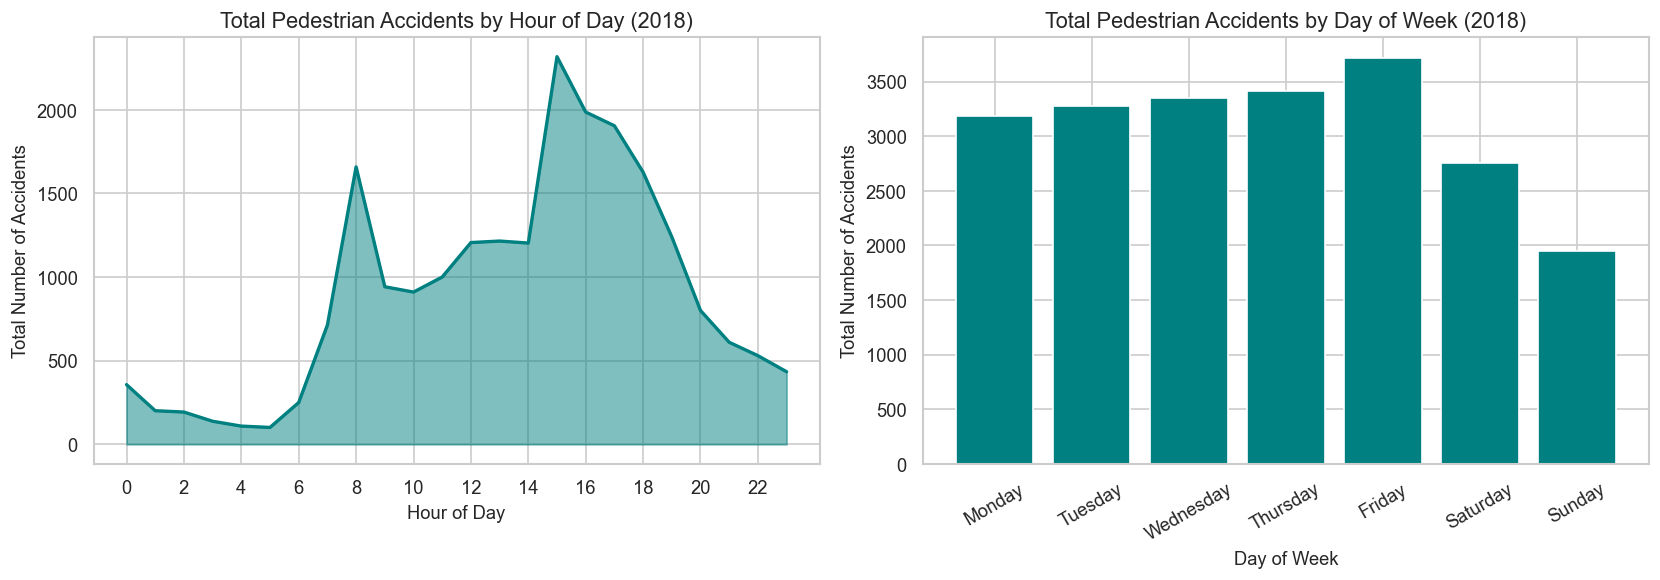

In [75]:
# Hourly and daily pedestrian accident counts
pedest_hourly = ped.groupby('hour').size().reset_index(name='count')
pedest_daily = ped.groupby('day_label').size().reindex(days_in_week).reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly area fill chart
axes[0].fill_between(pedest_hourly['hour'], pedest_hourly['count'], color='teal', alpha=0.5)
axes[0].plot(pedest_hourly['hour'], pedest_hourly['count'], color='teal', linewidth=2)
axes[0].set_title('Total Pedestrian Accidents by Hour of Day (2018)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Number of Accidents')
axes[0].set_xticks(range(0, 24, 2))

# Daily bar chart
axes[1].bar(pedest_daily['day_label'], pedest_daily['count'], color='teal')
axes[1].set_title('Total Pedestrian Accidents by Day of Week (2018)')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Number of Accidents')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('3_pedestrian_accidents.png', bbox_inches='tight')
plt.show()

In [76]:
# Key pedestrian statss
peak_pedest_hour = pedest_hourly.loc[pedest_hourly['count'].idxmax()]
peak_pedest_day = pedest_daily.loc[pedest_daily['count'].idxmax()]
print(f"Peak pedestrian accident hour : {int(peak_pedest_hour['hour'])}:00 {int(peak_pedest_hour['count']):,} accidents")
print(f"Peak pedestrian accident day : {peak_pedest_day['day_label']} {int(peak_pedest_day['count']):,} accidents")

Peak pedestrian accident hour : 15:00 2,317 accidents
Peak pedestrian accident day : Friday 3,720 accidents


---
#### Impact of Variables on Accident Severity (Apriori, 2018)

In [77]:
# Building itemsets from key categorical features
apriori_df = acc_2018[['severity_label', 'light_label', 'weather_label', 'road_surf_label', 'speed_label', 'urban_label']].copy()

# Binning hour into time periods to include in itemsets
apriori_df['time_period'] = pd.cut(acc_2018['hour'], bins=[-1, 5, 11, 17, 20, 23], 
                                   labels=['Night(0-5)', 'Morning(6-11)', 'Afternoon(12-17)', 'Evening(18-20)', 'Late-Night(21-23)'])

# Removing rows where any feature is unknown or unclassified
apriori_df = apriori_df[~apriori_df.isin(['Unknown']).any(axis=1)].dropna()
print(f"Records for Apriori: {len(apriori_df):,}")

Records for Apriori: 118,608


In [78]:
# Creating prefixed transaction items to distinguish columns with shared label names
def make_transaction(row):
    return [f"SEV:{row['severity_label']}", f"LIGHT:{row['light_label']}", f"WTHR:{row['weather_label']}", f"SURF:{row['road_surf_label']}",
        f"SPD:{row['speed_label']}", f"AREA:{row['urban_label']}", f"TIME:{row['time_period']}"]

transactions = apriori_df.apply(make_transaction, axis=1).tolist()
print("Sample transaction:", transactions[0])

Sample transaction: ['SEV:Serious', 'LIGHT:Daylight', 'WTHR:Fine', 'SURF:Dry', 'SPD:60mph', 'AREA:Rural', 'TIME:Evening(18-20)']


In [79]:
# Encoding and running the Apriori algorithm (min support = 0.05)
transaction_enc = TransactionEncoder()
transaction_array = transaction_enc.fit_transform(transactions)
te_df = pd.DataFrame(transaction_array, columns=transaction_enc.columns_)

frequent_itemsets = apriori(te_df, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.nlargest(10, 'support')[['support', 'itemsets']].to_string())

Frequent itemsets found: 489
      support                     itemsets
19   0.834455                  (WTHR:Fine)
6    0.796616                 (SEV:Slight)
12   0.742994                   (SURF:Dry)
102  0.723821        (SURF:Dry, WTHR:Fine)
4    0.722767             (LIGHT:Daylight)
1    0.669811                 (AREA:Urban)
81   0.662569      (WTHR:Fine, SEV:Slight)
64   0.631113  (WTHR:Fine, LIGHT:Daylight)
8    0.595188                  (SPD:30mph)
75   0.592060       (SURF:Dry, SEV:Slight)


In [80]:
# Generating association rules and filtering for severity as the consequent
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

sev_rules = rules[rules['consequents'].apply(lambda x: any('SEV:' in item for item in x))].copy()
sev_rules = sev_rules.sort_values('lift', ascending=False)

print(f"Rules with severity as consequent: {len(sev_rules)}")
print("\nTop 15 rules by lift:")
print(sev_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string())

Rules with severity as consequent: 1733

Top 15 rules by lift:
                       antecedents                              consequents   support  confidence      lift
1420   (SURF:Wet/Damp, AREA:Urban)               (WTHR:Raining, SEV:Slight)  0.056472    0.389396  4.482721
1424                (WTHR:Raining)  (SURF:Wet/Damp, AREA:Urban, SEV:Slight)  0.056472    0.525457  4.450718
1422    (WTHR:Raining, AREA:Urban)              (SURF:Wet/Damp, SEV:Slight)  0.056472    0.805048  4.326468
628                 (WTHR:Raining)              (SURF:Wet/Damp, SEV:Slight)  0.084446    0.785754  4.222775
627                (SURF:Wet/Damp)               (WTHR:Raining, SEV:Slight)  0.084446    0.359370  4.137062
1423               (SURF:Wet/Damp)   (WTHR:Raining, AREA:Urban, SEV:Slight)  0.056472    0.240321  4.135817
2349       (AREA:Rural, WTHR:Fine)        (SURF:Dry, SPD:60mph, SEV:Slight)  0.052206    0.193870  3.421289
2347        (SURF:Dry, AREA:Rural)       (WTHR:Fine, SPD:60mph, SEV:Sligh

C:\Users\saadm\AppData\Local\Temp\ipykernel_20976\954189497.py:15: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\saadm\AppData\Local\Temp\ipykernel_20976\954189497.py:16: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig('4_apriori_rules.png', bbox_inches='tight')
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


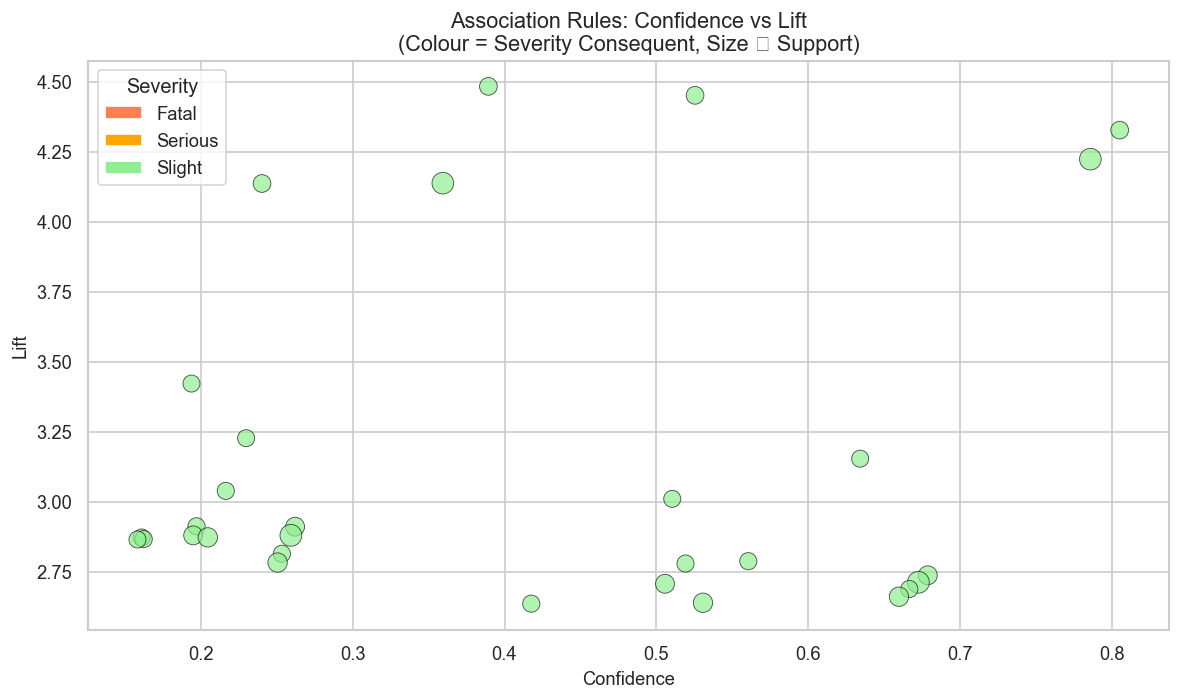

In [81]:
# Plotting confidence vs lift for top severity rules
top_rules = sev_rules.head(30).copy()

sev_colours = {'Fatal': 'coral', 'Serious': 'orange', 'Slight': 'lightgreen'}
top_rules['colour'] = top_rules['consequents'].apply(lambda x: sev_colours.get(next((i.replace('SEV:', '') for i in x if 'SEV:' in i), 'Slight'), 'gray'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(top_rules['confidence'], top_rules['lift'], c=top_rules['colour'], s=top_rules['support'] * 2000, alpha=0.7, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.set_title('Association Rules: Confidence vs Lift\n(Colour = Severity Consequent, Size ∝ Support)')

legend_elements = [Patch(fc='coral', label='Fatal'), Patch(fc='orange', label='Serious'), Patch(fc='lightgreen', label='Slight')]
ax.legend(handles=legend_elements, title='Severity')
plt.tight_layout()
plt.savefig('4_apriori_rules.png', bbox_inches='tight')
plt.show()

---
#### Clustering of West Yorkshire Accidents (2018)

In [82]:
# Filtering West Yorkshire accidents (police_force == 13) with valid coordinates
wy_2018 = acc_2018[acc_2018['police_force'] == 13].copy()
wy_2018 = wy_2018.dropna(subset=['latitude', 'longitude'])
wy_2018 = wy_2018[(wy_2018['latitude'] > 53.0) & (wy_2018['latitude'] < 54.0) & (wy_2018['longitude'] > -2.5) & (wy_2018['longitude'] < -0.5)]

print(f"West Yorkshire 2018 accidents (valid coordinates): {len(wy_2018):,}")
print(wy_2018[['latitude', 'longitude']].describe())

West Yorkshire 2018 accidents (valid coordinates): 4,132
          latitude    longitude
count  4132.000000  4132.000000
mean     53.757011    -1.640233
std       0.074106     0.166658
min      53.539703    -2.140799
25%      53.699914    -1.771568
50%      53.774560    -1.634292
75%      53.808133    -1.527500
max      53.941119    -1.228992


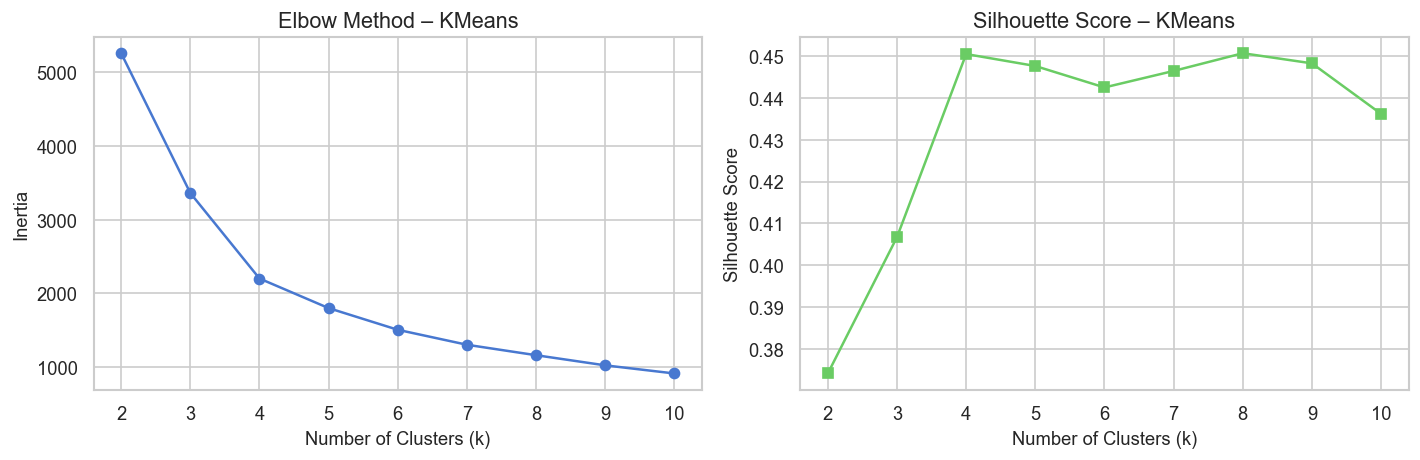

Best k by silhouette score: 8


In [83]:
# Scaling coordinates and finding the optimal number of clusters (Elbow + Silhouette)
coords = wy_2018[['latitude', 'longitude']].values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

inertias = []
sil_scores = []

k_range = range(2, 11)

for k in k_range:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = k_means.fit_predict(coords_scaled)
    inertias.append(k_means.inertia_)
    sil_scores.append(silhouette_score(coords_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method – KMeans')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, sil_scores, 'gs-')
axes[1].set_title('Silhouette Score – KMeans')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('5_elbow_silhouette.png', bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette score: {best_k}")

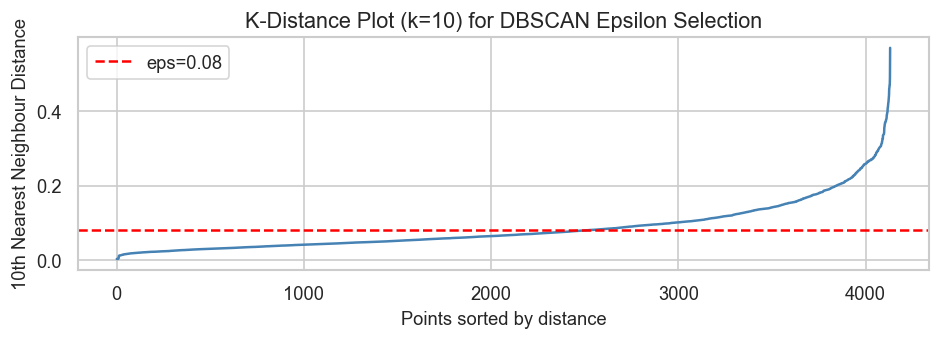

KMeans clusters : 8
DBSCAN clusters : 68 | Noise points: 10.6%

KMeans cluster sizes:
kmeans_cluster
0     810
1     403
2     450
3    1207
4     377
5     257
6     303
7     325
Name: count, dtype: int64


In [84]:
# Fitting KMeans with best k and DBSCAN for comparison
k_means_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
wy_2018 = wy_2018.copy()
wy_2018['kmeans_cluster'] = k_means_final.fit_predict(coords_scaled)

# K-distance plot to determine optimal eps for DBSCAN
nbrs = NearestNeighbors(n_neighbors=10).fit(coords_scaled)
distances, _ = nbrs.kneighbors(coords_scaled)
distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 3))
plt.plot(distances, color='steelblue')
plt.axhline(y=0.08, color='red', linestyle='--', label='eps=0.08')
plt.title('K-Distance Plot (k=10) for DBSCAN Epsilon Selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('10th Nearest Neighbour Distance')
plt.legend()
plt.tight_layout()
plt.savefig('5_kdistance.png', bbox_inches='tight')
plt.show()

# Density based clustering to not require pre specifying k
db = DBSCAN(eps=0.08, min_samples=5)
wy_2018['dbscan_cluster'] = db.fit_predict(coords_scaled)

n_db_clusters = len(set(wy_2018['dbscan_cluster'])) - (1 if -1 in wy_2018['dbscan_cluster'].values else 0)
noise_pct = (wy_2018['dbscan_cluster'] == -1).sum() / len(wy_2018) * 100

print(f'KMeans clusters : {best_k}')
print(f'DBSCAN clusters : {n_db_clusters} | Noise points: {noise_pct:.1f}%')
print('\nKMeans cluster sizes:')
print(wy_2018['kmeans_cluster'].value_counts().sort_index())

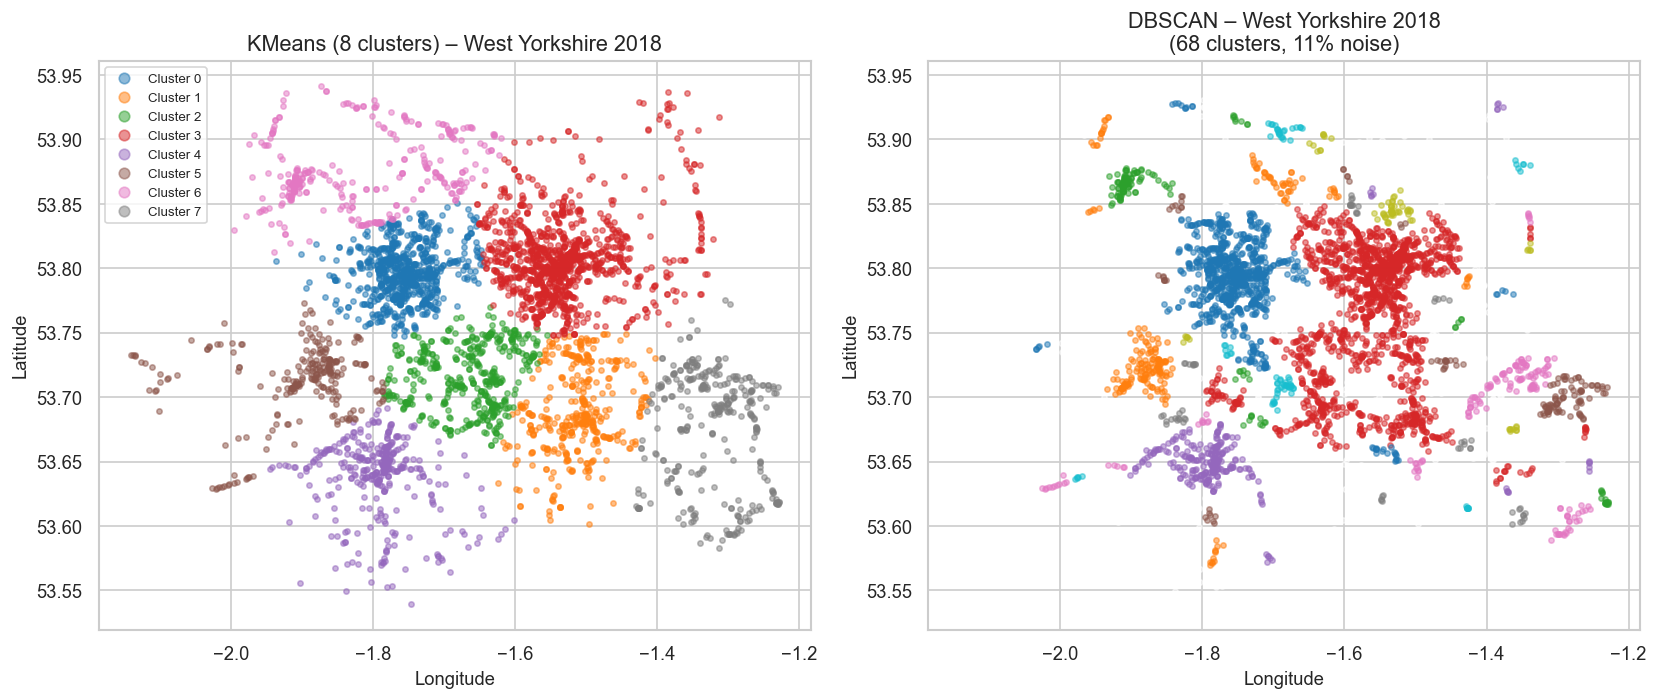

In [85]:
# Plotting KMeans and DBSCAN clusters side by side on geographic coordinates
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans scatter
palette_k = sns.color_palette('tab10', best_k)
for cid in sorted(wy_2018['kmeans_cluster'].unique()):
    sub = wy_2018[wy_2018['kmeans_cluster'] == cid]
    axes[0].scatter(sub['longitude'], sub['latitude'], s=10, alpha=0.5, label=f'Cluster {cid}', color=palette_k[cid])
axes[0].set_title(f'KMeans ({best_k} clusters) – West Yorkshire 2018')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=2, fontsize=8)

# DBSCAN scatter
db_clusters = sorted(wy_2018['dbscan_cluster'].unique())
palette_d = sns.color_palette('tab10', n_db_clusters)
colour_db = {-1: 'white'}
colour_db.update({c: palette_d[i] for i, c in enumerate(c for c in db_clusters if c != -1)})
for cid in db_clusters:
    sub = wy_2018[wy_2018['dbscan_cluster'] == cid]
    label = 'Noise' if cid == -1 else f'Cluster {cid}'
    axes[1].scatter(sub['longitude'], sub['latitude'], s=10, alpha=0.5, label=label, color=colour_db[cid])
axes[1].set_title(f'DBSCAN – West Yorkshire 2018\n({n_db_clusters} clusters, {noise_pct:.0f}% noise)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
#axes[1].legend(markerscale=2, fontsize=7)

plt.tight_layout()
plt.savefig('5_clustering_wy.png', bbox_inches='tight')
plt.show()

Severity distribution per cluster (%):

severity_label  Fatal  Serious  Slight
kmeans_cluster                        
0                 1.1     15.4    83.5
1                 1.7     19.1    79.2
2                 2.0     15.8    82.2
3                 1.3     18.6    80.1
4                 0.8     15.1    84.1
5                 1.2     21.4    77.4
6                 2.3     18.5    79.2
7                 2.8     22.8    74.5


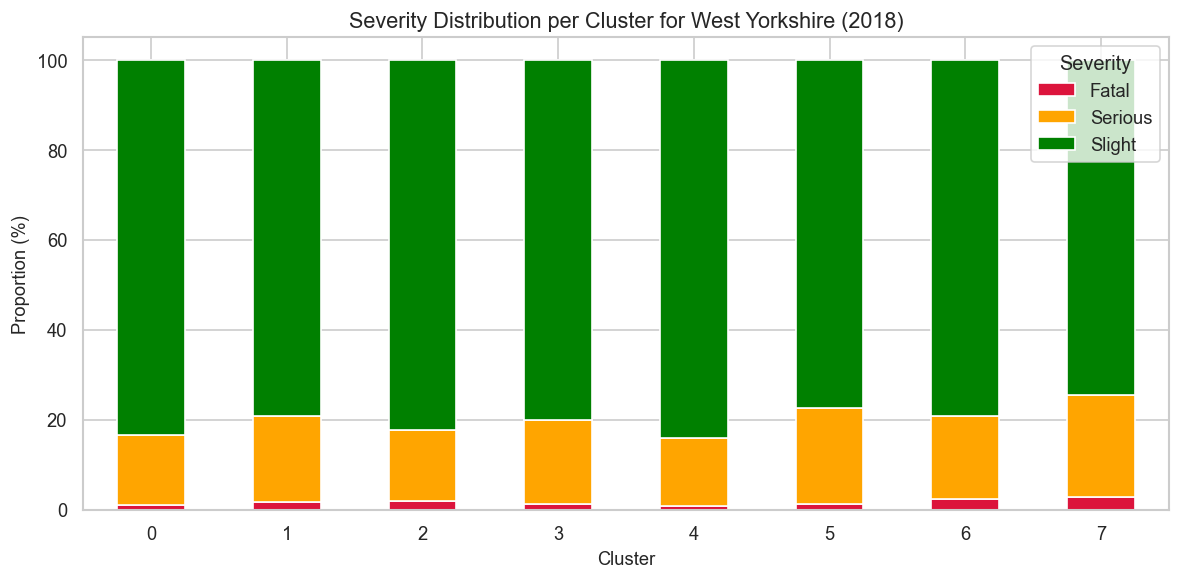

In [86]:
# Severity distribution per KMeans cluster
cluster_sev = (wy_2018.groupby(['kmeans_cluster', 'severity_label']).size().unstack(fill_value=0))
cluster_sev_pct = cluster_sev.div(cluster_sev.sum(axis=1), axis=0) * 100

print("Severity distribution per cluster (%):\n")
print(cluster_sev_pct.round(1).to_string())

cluster_sev_pct.plot(kind='bar', stacked=True, figsize=(10, 5), color=['crimson', 'orange', 'green'], rot=0)
plt.title('Severity Distribution per Cluster for West Yorkshire (2018)')
plt.xlabel('Cluster')
plt.ylabel('Proportion (%)')
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig('5_cluster_severity_profile.png', bbox_inches='tight')
plt.show()

---
#### Weekly Accident Counts by Police Force

Three policing areas are selected: Metropolitan (1), Greater Manchester (6), and West Yorkshire (13). Models will be trained on 2017–2018 weekly accidents then forecast 2019.

In [87]:
# Building weekly accident count series for each police force
selected_forces = {1: 'Metropolitan', 6: 'Greater Manchester', 13: 'West Yorkshire'}

def build_weekly_series(df, force_code, years):
    subset = df[(df['police_force'] == force_code) & (df['accident_year'].isin(years))].copy()
    subset['date_parsed'] = pd.to_datetime(subset['date'], dayfirst=True, errors='coerce')
    subset['week_start'] = subset['date_parsed'].dt.to_period('W').apply(lambda r: r.start_time)
    weekly = (subset.groupby('week_start').size().reset_index(name='count').set_index('week_start').sort_index())
    return weekly

weekly_series = {}
for code, name in selected_forces.items():
    train = build_weekly_series(acc_all, code, [2017, 2018])
    test = build_weekly_series(acc_all, code, [2019])
    weekly_series[code] = {'name': name, 'train': train, 'test': test}
    print(f"{name}: {len(train)} training weeks, {len(test)} test weeks")

Metropolitan: 106 training weeks, 53 test weeks
Greater Manchester: 106 training weeks, 53 test weeks
West Yorkshire: 106 training weeks, 53 test weeks


In [88]:
# Stationary check using the Augmented Dickey-Fuller test
print("ADF Test Results (p < 0.05 = stationary):")
for code, data in weekly_series.items():
    series = data['train']['count'].dropna()
    result = adfuller(series, autolag='AIC')
    status = 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    print(f"{data['name']} | ADF={result[0]:.3f} | p={result[1]:.4f} | {status}")

ADF Test Results (p < 0.05 = stationary):
Metropolitan | ADF=-3.422 | p=0.0102 | Stationary
Greater Manchester | ADF=-6.722 | p=0.0000 | Stationary
West Yorkshire | ADF=-6.689 | p=0.0000 | Stationary


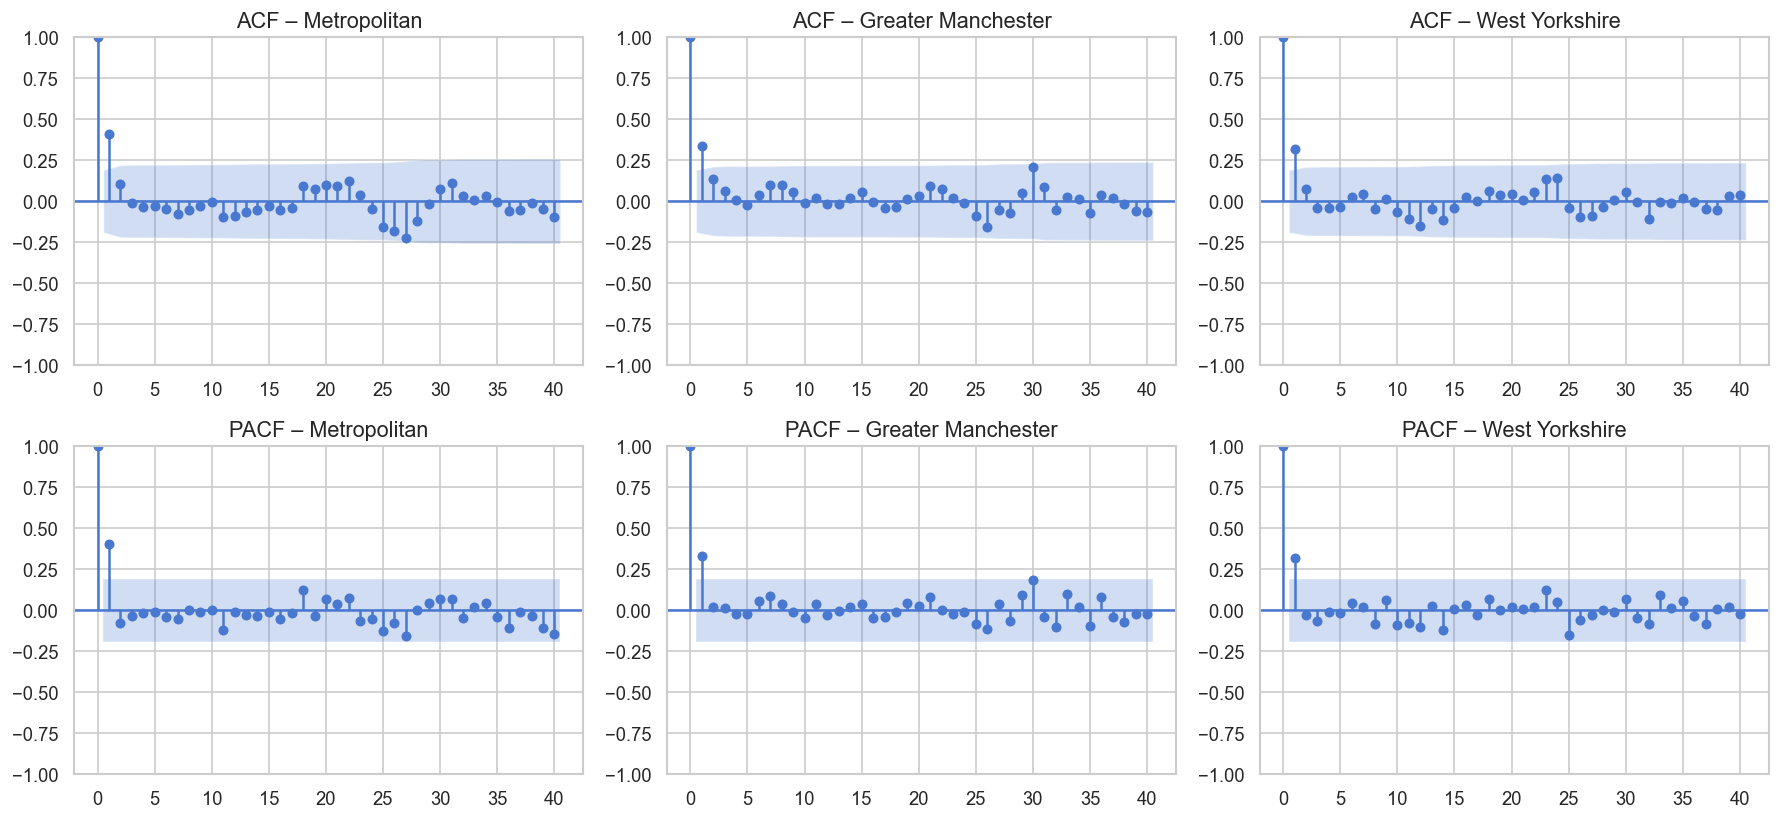

In [89]:
# ACF and PACF plots to identify and justify SARIMA order (p, q)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (code, data) in enumerate(weekly_series.items()):
    series = data['train']['count'].dropna()
    plot_acf(series, ax=axes[0][i], lags=40, title=f"ACF – {data['name']}")
    plot_pacf(series, ax=axes[1][i], lags=40, title=f"PACF – {data['name']}")
plt.tight_layout()
plt.savefig('6_acf_pacf.png', bbox_inches='tight')
plt.show()

In [90]:
# Seasonal period of 52 annual weekly accidents pattern
sarima_order = (1, 1, 1)
seasonal_order = (1, 1, 0, 52) # SARIMA(1,1,1)(1,1,0,52)
forecast_results = {}

for code, data in weekly_series.items():
    name = data['name']
    train = data['train']['count']
    test = data['test']['count']

    model = SARIMAX(train, order=sarima_order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)

    forecast = fit.get_forecast(steps=len(test))
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()
    forecast_mean.index = test.index[:len(forecast_mean)]
    forecast_ci.index = test.index[:len(forecast_ci)]

    mae = np.mean(np.abs(test.values[:len(forecast_mean)] - forecast_mean.values))
    rmse = np.sqrt(np.mean((test.values[:len(forecast_mean)] - forecast_mean.values) ** 2))

    forecast_results[code] = {'name': name, 'train': train, 'test': test, 'forecast': forecast_mean, 'ci': forecast_ci, 'mae': mae, 'rmse': rmse, 'fit': fit}
    print(f'{name}: MAE = {mae:.1f}, RMSE = {rmse:.1f}, AIC = {fit.aic:.1f}')

c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W

Metropolitan: MAE = 250.0, RMSE = 275.5, AIC = 8.0


c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


Greater Manchester: MAE = 72.2, RMSE = 78.9, AIC = 8.0
West Yorkshire: MAE = 57.4, RMSE = 64.1, AIC = 8.0


c:\Users\saadm\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


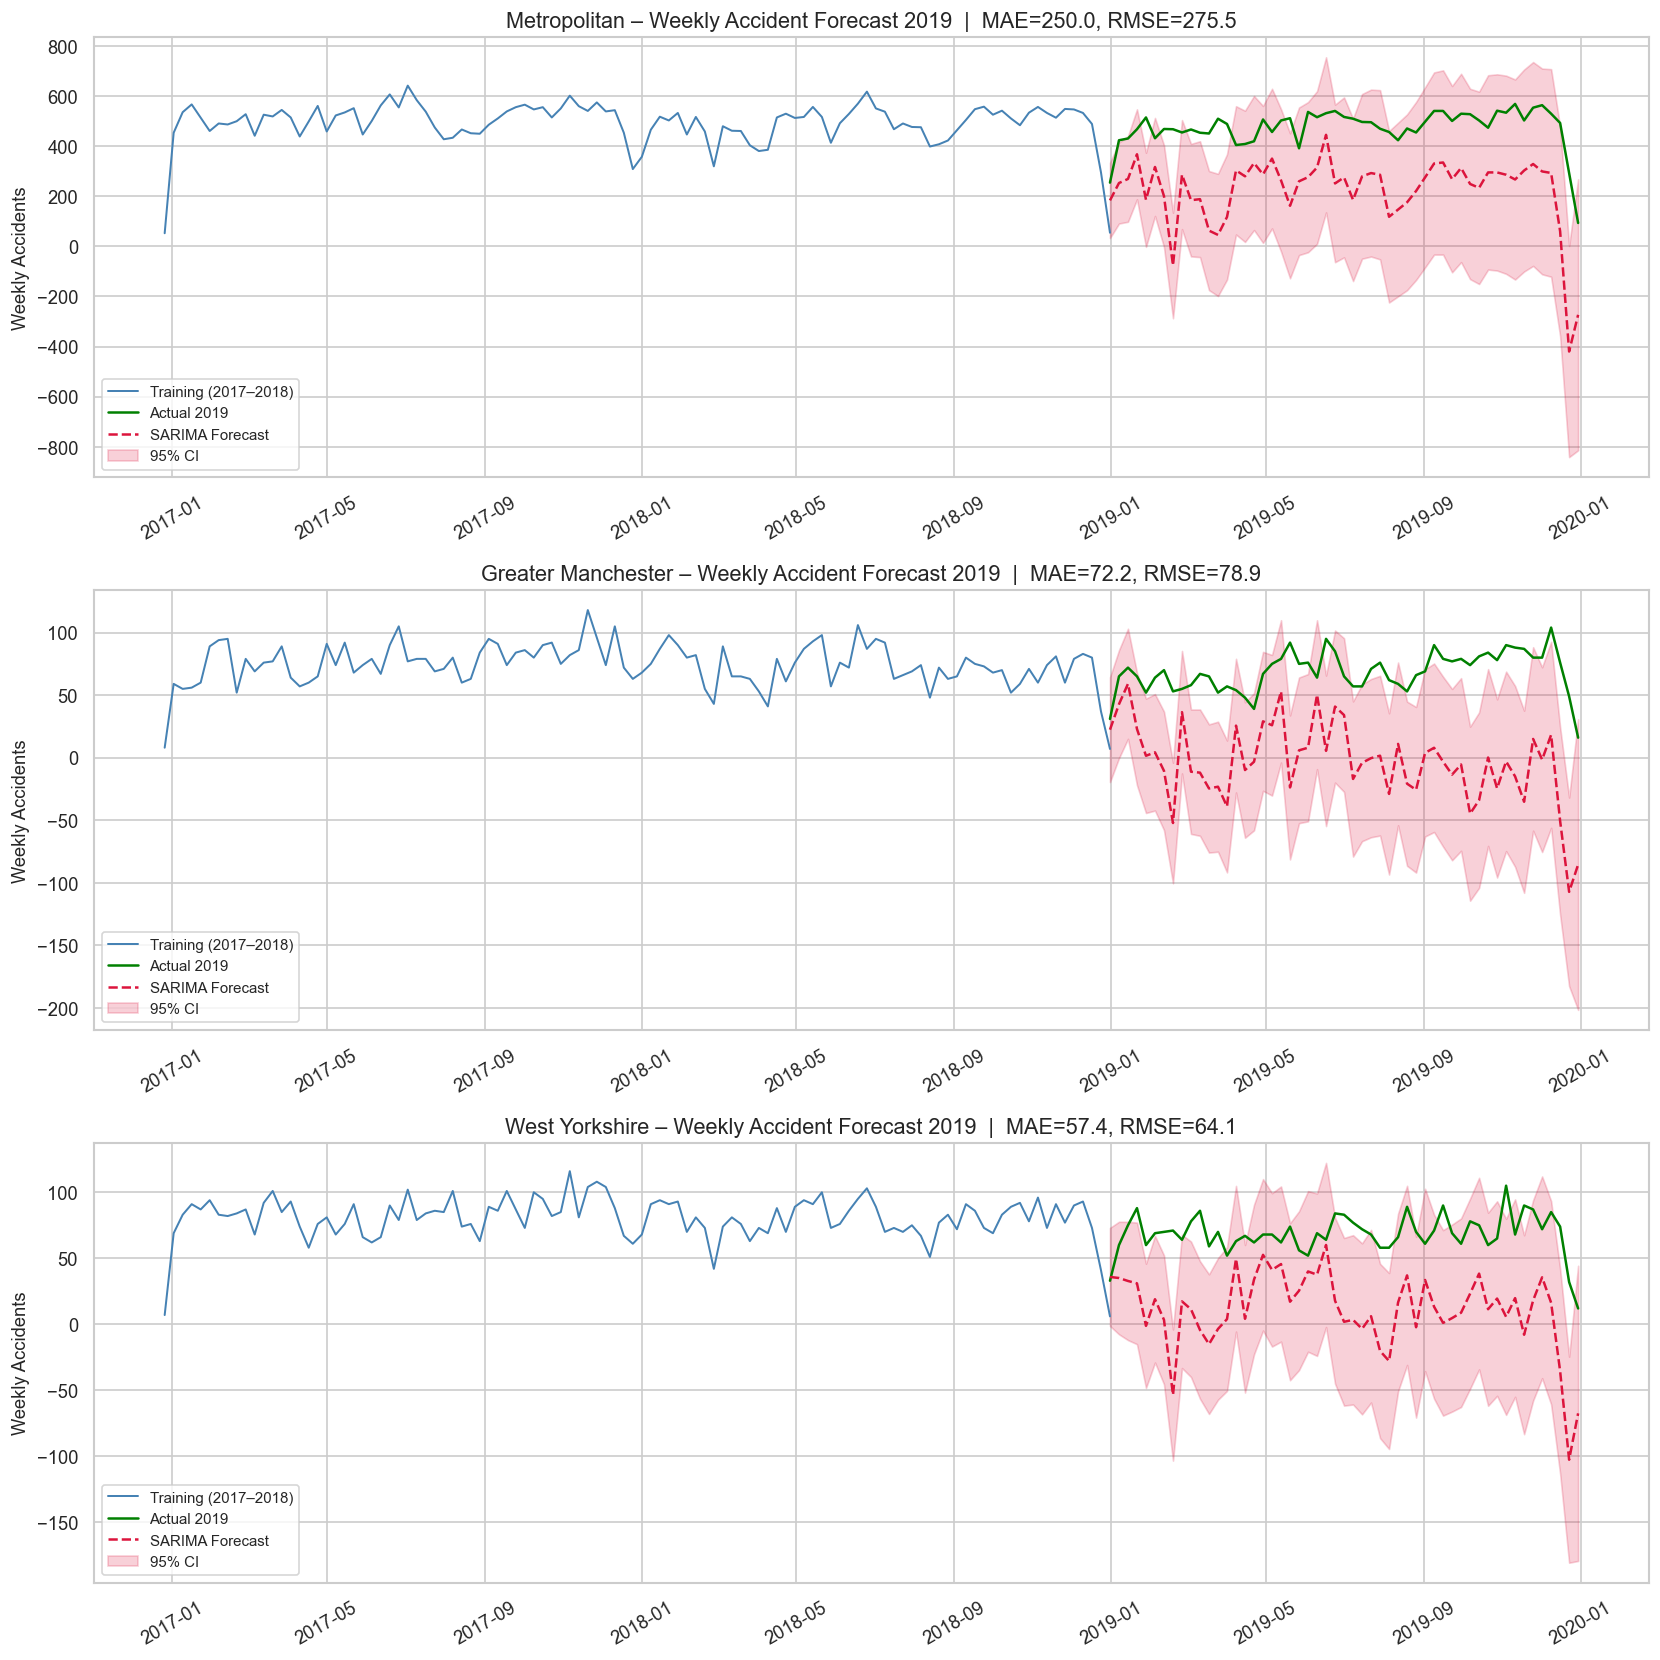

In [91]:
# Plotting forecast vs actual for each police force
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, (code, res) in zip(axes, forecast_results.items()):
    ax.plot(res['train'].index, res['train'].values, color='steelblue', label='Training (2017–2018)', linewidth=1.2)
    ax.plot(res['test'].index, res['test'].values, color='green', label='Actual 2019', linewidth=1.5)
    ax.plot(res['forecast'].index, res['forecast'].values, color='crimson', linestyle='--', label='SARIMA Forecast', linewidth=1.5)
    ax.fill_between(res['forecast'].index, res['ci'].iloc[:, 0], res['ci'].iloc[:, 1], alpha=0.2, color='crimson', label='95% CI')
    ax.set_title(f"{res['name']} – Weekly Accident Forecast 2019  |  MAE={res['mae']:.1f}, RMSE={res['rmse']:.1f}")
    ax.set_ylabel('Weekly Accidents')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('6_sarima_forecasts.png', bbox_inches='tight')
plt.show()

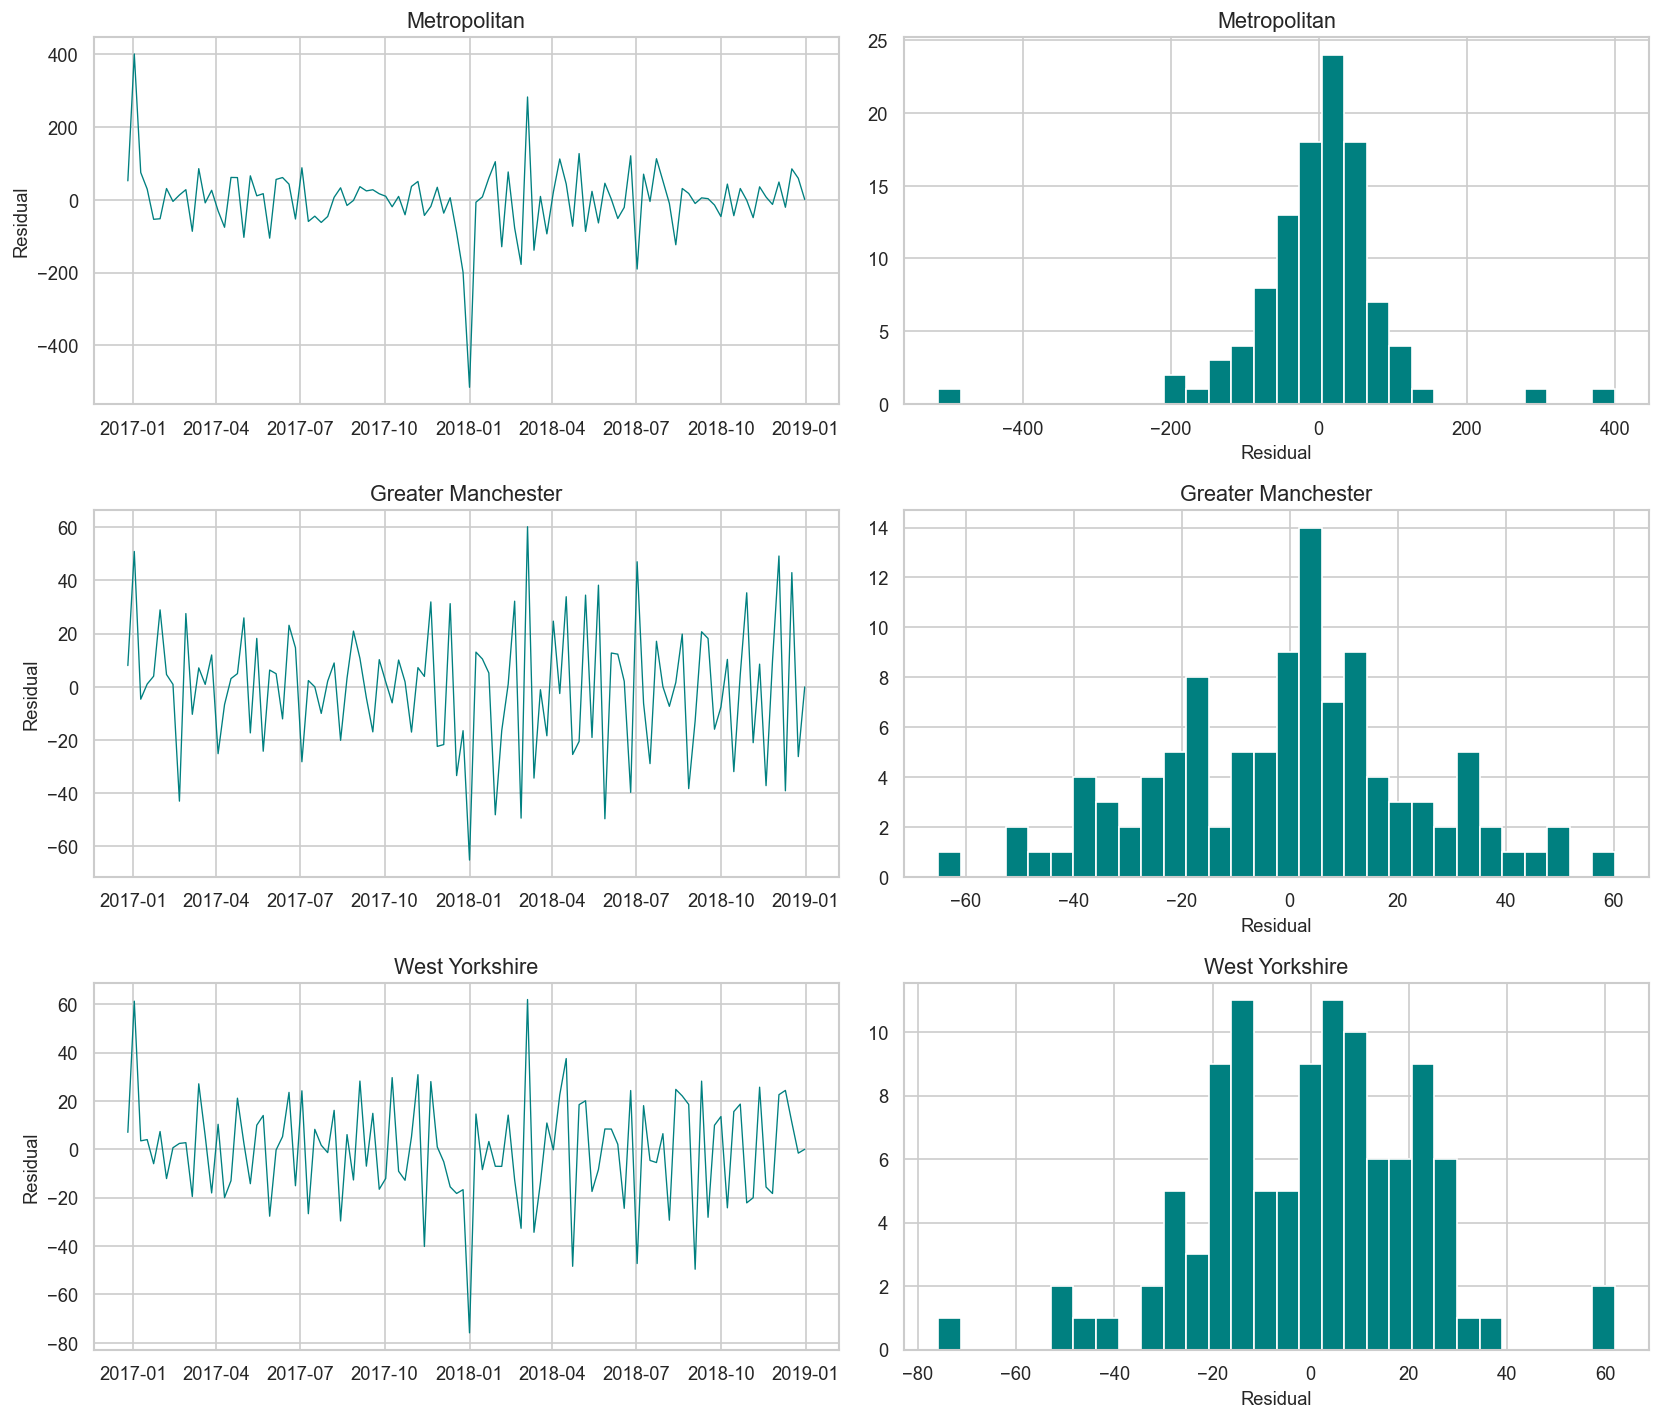

In [92]:
# Checking for white noise in residuals
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for i, (code, res) in enumerate(forecast_results.items()):
    residuals = res['fit'].resid
    axes[i][0].plot(residuals, color='teal', linewidth=0.8)
    axes[i][0].set_title(f"{res['name']}")
    axes[i][0].set_ylabel('Residual')
    axes[i][1].hist(residuals, bins=30, color='teal', edgecolor='white')
    axes[i][1].set_title(f"{res['name']}")
    axes[i][1].set_xlabel('Residual')
plt.tight_layout()
plt.savefig('6_sarima_residuals.png', bbox_inches='tight')
plt.show()

---
#### Top 30 West Yorkshire LSOAs

In [93]:
# Identifying the top 30 LSOAs in West Yorkshire by Q1 2018 accident count
wy_q1 = acc_2018[(acc_2018['police_force'] == 13) & (acc_2018['timestamp'].dt.month <= 3) & 
                 (acc_2018['lsoa_of_accident_location'].notna()) & (acc_2018['lsoa_of_accident_location'] != '')].copy()

top30_lsoa = (wy_q1.groupby('lsoa_of_accident_location').size().nlargest(30).reset_index(name='q1_count'))
top30_lsoa.columns = ['lsoa', 'q1_count']

print("Top 30 West Yorkshire LSOAs by Q1 2018 accident count:")
print(top30_lsoa.to_string(index=False))

Top 30 West Yorkshire LSOAs by Q1 2018 accident count:
     lsoa  q1_count
E01011499        11
E01011107         8
E01033010         8
E01033693         8
E01010833         7
E01011236         7
E01011369         7
E01011569         6
E01011935         6
E01033005         6
E01010979         5
E01011130         5
E01011205         5
E01011297         5
E01011363         5
E01011428         5
E01011468         5
E01011523         5
E01011677         5
E01033031         5
E01010613         4
E01010639         4
E01010834         4
E01010879         4
E01010934         4
E01010949         4
E01010994         4
E01011029         4
E01011048         4
E01011057         4


In [94]:
# Aggregating daily accident counts for these 30 LSOAs across Jan–Jun 2018
top30_list = top30_lsoa['lsoa'].tolist()

wy_h1 = acc_2018[
    (acc_2018['lsoa_of_accident_location'].isin(top30_list)) &
    (acc_2018['timestamp'].dt.month <= 6)
].copy()

wy_daily = (wy_h1.groupby(wy_h1['timestamp'].dt.date).size().reset_index(name='count'))
wy_daily.columns = ['date', 'count']
wy_daily['date'] = pd.to_datetime(wy_daily['date'])
wy_daily = wy_daily.set_index('date').sort_index()

# Filling any missing days with zero
full_idx = pd.date_range(wy_daily.index.min(), wy_daily.index.max(), freq='D')
wy_daily = wy_daily.reindex(full_idx, fill_value=0)

print(f"Training series: {len(wy_daily)} days")
print(wy_daily.describe())

Training series: 180 days
            count
count  180.000000
mean     1.538889
std      1.238867
min      0.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      6.000000


In [95]:
# ADF stationarity test on the daily series
adf_result = adfuller(wy_daily['count'], autolag='AIC')
print(f"ADF statistic : {adf_result[0]:.3f}")
print(f"p-value : {adf_result[1]:.4f}")
print('Stationary' if adf_result[1] < 0.05 else 'Non-stationary')

ADF statistic : -3.409
p-value : 0.0107
Stationary


In [96]:
# Fitting ARIMA(2,1,2) on Jan–6 2018 daily data
model_t7 = ARIMA(wy_daily['count'], order=(2, 1, 2))
fit_t7 = model_t7.fit()
print(fit_t7.summary())

                               SARIMAX Results                                
Dep. Variable:                  count   No. Observations:                  180
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -283.047
Date:                Mon, 04 May 2026   AIC                            576.093
Time:                        20:38:55   BIC                            592.030
Sample:                    01-01-2018   HQIC                           582.556
                         - 06-29-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7778      0.112     -6.922      0.000      -0.998      -0.558
ar.L2         -0.2220      0.084     -2.651      0.008      -0.386      -0.058
ma.L1         -0.1526      0.092     -1.651      0.0

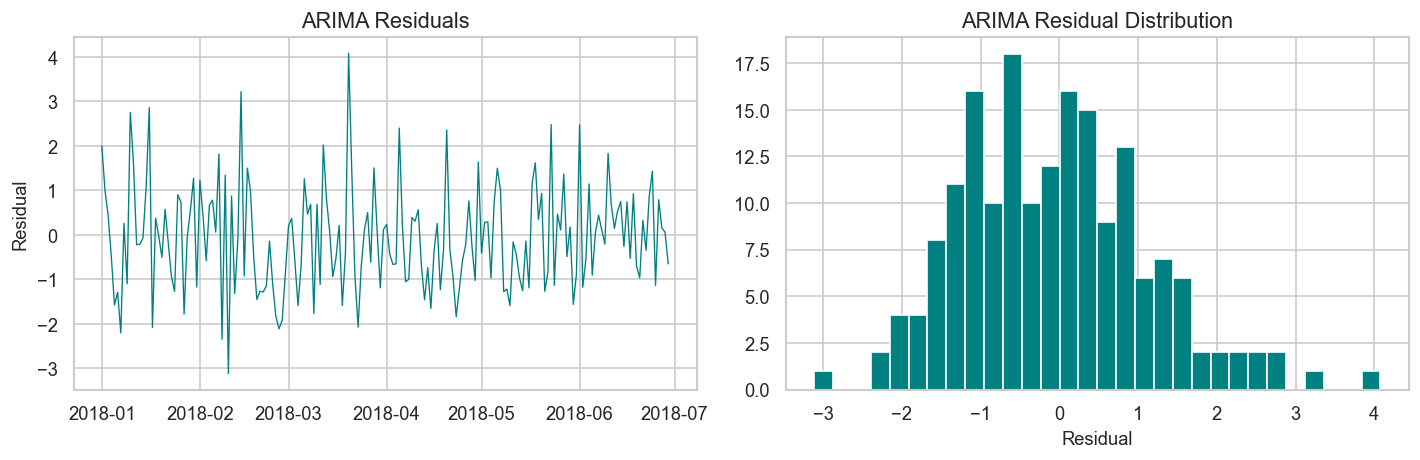

In [97]:
# ARIMA residual diagnostics – confirming white noise in residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
residuals_t7 = fit_t7.resid
axes[0].plot(residuals_t7, color='teal', linewidth=0.8)
axes[0].set_title('ARIMA Residuals')
axes[0].set_ylabel('Residual')
axes[1].hist(residuals_t7, bins=30, color='teal', edgecolor='white')
axes[1].set_title('ARIMA Residual Distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.savefig('7_arima_residuals.png', bbox_inches='tight')
plt.show()

In [98]:
# Forecasting daily accident counts for July 2018
forecast_t7 = fit_t7.get_forecast(steps=31)
forecast_mean = forecast_t7.predicted_mean
forecast_ci = forecast_t7.conf_int()

july_idx = pd.date_range(start=wy_daily.index[-1] + pd.Timedelta(days=1), periods=31, freq='D')
forecast_mean.index = july_idx
forecast_ci.index = july_idx

# Pulling actual July 2018 data for the top 30 LSOAs
wy_july_actual = acc_2018[(acc_2018['lsoa_of_accident_location'].isin(top30_list)) & (acc_2018['timestamp'].dt.month == 7)
                          ].groupby(acc_2018['timestamp'].dt.date).size().reset_index(name='count')
wy_july_actual.columns = ['date', 'count']
wy_july_actual['date'] = pd.to_datetime(wy_july_actual['date'])
wy_july_actual = wy_july_actual.set_index('date').reindex(july_idx, fill_value=0)

mae_t7 = np.mean(np.abs(wy_july_actual['count'].values - forecast_mean.values))
rmse_t7 = np.sqrt(np.mean((wy_july_actual['count'].values - forecast_mean.values) ** 2))
print(f'July 2018 Forecast – MAE: {mae_t7:.2f}, RMSE: {rmse_t7:.2f}')

July 2018 Forecast – MAE: 1.02, RMSE: 1.20


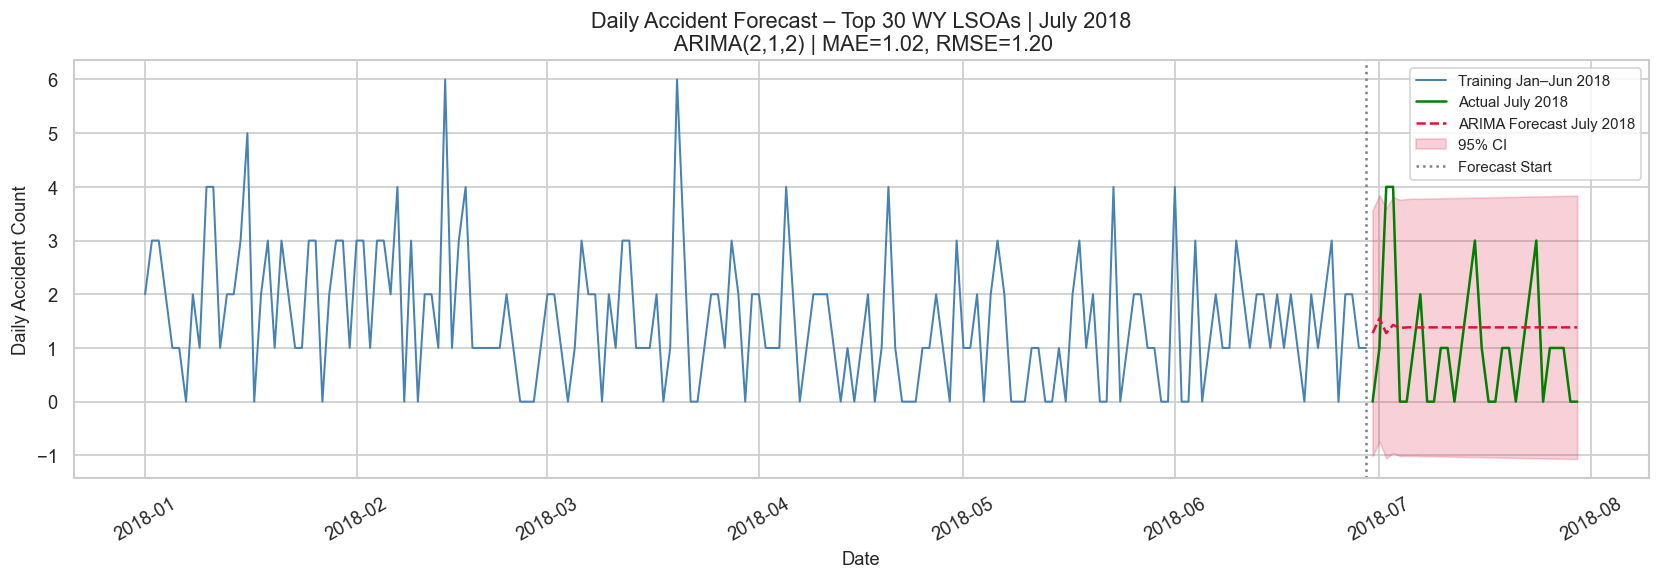

In [99]:
# Plotting training series, actual July, and forecast July
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(wy_daily.index, wy_daily['count'],  color='steelblue', label='Training Jan–Jun 2018', linewidth=1.2)
ax.plot(wy_july_actual.index, wy_july_actual['count'], color='green', label='Actual July 2018', linewidth=1.5)
ax.plot(forecast_mean.index, forecast_mean.values, color='crimson', linestyle='--', label='ARIMA Forecast July 2018', linewidth=1.5)
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], alpha=0.2, color='crimson', label='95% CI')
ax.axvline(x=wy_daily.index[-1], color='grey', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f'Daily Accident Forecast – Top 30 WY LSOAs | July 2018\n ARIMA(2,1,2) | MAE={mae_t7:.2f}, RMSE={rmse_t7:.2f}')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Accident Count')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('7_daily_forecast_july.png', bbox_inches='tight')
plt.show()

In [100]:
# Closing the database connection
con.close()